# V2a-RSNs Linear BSS Decomposition

This notebook decomposes the V2a-RSN calcium time series with FastICA, Infomax, SOBI, and JADE. It saves only decomposition artifacts needed by `clustering_methods.ipynb`: IC time courses, spectra, mixing matrix, mean vector, and metadata.

Artifacts are saved under `outputs/linear/<dataset_group>/<data_name>/<method>/` when `SAVE_DECOMPOSITION_OUTPUTS = True`.


In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np

candidates = [Path.cwd(), *Path.cwd().parents]
PROJECT_ROOT = next(
    p
    for p in candidates
    if (p / "pyproject.toml").exists() and (p / "src" / "bss_notebook.py").exists()
)
SRC_DIR = PROJECT_ROOT / "src"
CORE_DIR = SRC_DIR / "core"
for path in (SRC_DIR, CORE_DIR):
    path_str = str(path)
    if path_str not in sys.path:
        sys.path.insert(0, path_str)

from bss_notebook import (
    BSS_METHODS,
    available_datasets,
    load_traces,
    output_directory,
    run_bss_decomposition,
    summarize_decomposition_results,
)

plt.rcParams.update({
    "figure.figsize": (12, 4),
    "axes.spines.top": False,
    "axes.spines.right": False,
})
PROJECT_ROOT


PosixPath('/Users/sadiqadedayo/Documents/projects/ICA/ica-denoising')

In [2]:
available_datasets(PROJECT_ROOT)


,key,group,data_name,trace_path,exists,default_n_components,sample_rate_hz,notes
0,motorneurons/fish3_trace2_dff,motorneurons,fish3_trace2_dff,/Users/sadiqadedayo/Documents/projects/ICA/ica...,True,11,4.0000,Motorneuron dF/F traces.
1,motorneurons/gcM_restored,motorneurons,gcM_restored,/Users/sadiqadedayo/Documents/projects/ICA/ica...,True,11,4.0000,Restored motorneuron traces.
2,v2a-RSNs/220127_F4_run2_fluorescence,v2a-RSNs,220127_F4_run2_fluorescence,/Users/sadiqadedayo/Documents/projects/ICA/ica...,True,40,5.2962,V2a RSN fluorescence traces.
3,v2a-RSNs/220127_F4_run2_spike_rate,v2a-RSNs,220127_F4_run2_spike_rate,/Users/sadiqadedayo/Documents/projects/ICA/ica...,True,40,5.2962,V2a RSN spike-rate traces.
4,v2a-RSNs/220210_F1_run6_fluorescence,v2a-RSNs,220210_F1_run6_fluorescence,/Users/sadiqadedayo/Documents/projects/ICA/ica...,True,40,5.2962,V2a RSN fluorescence traces. Uses frameRateSCA...
5,v2a-RSNs/220210_F1_run6_spike_rate,v2a-RSNs,220210_F1_run6_spike_rate,/Users/sadiqadedayo/Documents/projects/ICA/ica...,True,40,5.2962,V2a RSN spike-rate traces. Uses frameRateSCAPE...


In [3]:
# Dataset and method selection
DATASET_KEY = "v2a-RSNs/220127_F4_run2_fluorescence"

# Use list(BSS_METHODS) to run all four methods, or choose a subset such as ["fastica"].
METHODS_TO_RUN = ["fastica", "infomax"] # list(BSS_METHODS)

# None uses one component per neuron/time series for this decomposition stage.
N_COMPONENTS = None
DECOMPOSITION_TOL = 0.0001
DECOMPOSITION_MAX_ITER = 500
DECOMPOSITION_RANDOM_STATE = 0

SAVE_DECOMPOSITION_OUTPUTS = True


In [4]:
dataset, traces = load_traces(DATASET_KEY, PROJECT_ROOT)
n_neurons, n_frames = traces.shape

# Use number of neurons/time series by default so clustering sees one IC slot per trace.
if N_COMPONENTS is not None:
    n_components = N_COMPONENTS
else:
    n_components = n_neurons

n_components = min(n_components, n_neurons, n_frames)

print(f"dataset: {dataset.key}")
print(f"trace file: {dataset.trace_path.relative_to(PROJECT_ROOT)}")
print(f"traces: neurons={n_neurons}, frames={n_frames}")
print(f"methods: {METHODS_TO_RUN}")
print(f"n_components: {n_components}")
for method in METHODS_TO_RUN:
    out_dir = output_directory(method, dataset.data_name, PROJECT_ROOT, dataset_group=dataset.group)
    print(f"{method} decomposition dir: {out_dir.relative_to(PROJECT_ROOT)}")


dataset: v2a-RSNs/220127_F4_run2_fluorescence
trace file: data/v2a-RSNs/new_data_09112022/220127_F4_run2/220127_F4_F4_run2_after_dec_cells_fluorescence_signals.npy
traces: neurons=844, frames=3176
methods: ['fastica', 'infomax']
n_components: 844
fastica decomposition dir: outputs/linear/v2a-RSNs/220127_F4_run2_fluorescence/fastica
infomax decomposition dir: outputs/linear/v2a-RSNs/220127_F4_run2_fluorescence/infomax


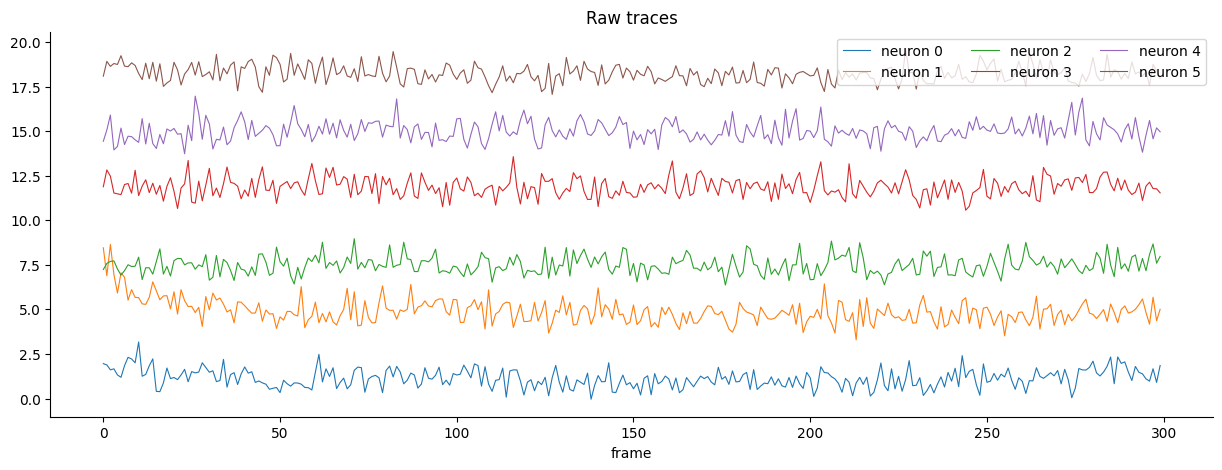

In [5]:
fig, ax = plt.subplots(figsize=(15, 5))
time_slice = slice(0, min(300, n_frames))
offset = np.nanstd(traces[:, time_slice]) * .4
if not np.isfinite(offset) or offset == 0:
    offset = 1.0
for neuron_idx in range(min(6, n_neurons)):
    ax.plot(
        np.arange(time_slice.start, time_slice.stop),
        traces[neuron_idx, time_slice] + neuron_idx * offset,
        lw=0.8,
        label=f"neuron {neuron_idx}",
    )
ax.set_title("Raw traces")
ax.set_xlabel("frame")
ax.legend(loc="upper right", ncols=3);


In [6]:
print(f"\n{'='*60}")
print(f"Running {len(METHODS_TO_RUN)} decompositions with {n_components} components...")
print(f"{'='*60}\n")

results = {}
for idx, method in enumerate(METHODS_TO_RUN, 1):
    print(f"[{idx}/{len(METHODS_TO_RUN)}] Fitting {method.upper()}...", flush=True)
    results[method] = run_bss_decomposition(
        dataset_key=DATASET_KEY,
        method=method,
        n_components=n_components,
        save_outputs=SAVE_DECOMPOSITION_OUTPUTS,
        project_root=PROJECT_ROOT,
        tol=DECOMPOSITION_TOL,
        max_iter=DECOMPOSITION_MAX_ITER,
        random_state=DECOMPOSITION_RANDOM_STATE,
    )
    print(f"  {method.upper()} completed\n", flush=True)

print(f"{'='*60}")
print("All decompositions completed successfully!")
print(f"{'='*60}\n")

summarize_decomposition_results(results)


Running 2 decompositions with 844 components...

[1/2] Fitting FASTICA...


/Users/sadiqadedayo/Documents/projects/ICA/ica-denoising/.venv/lib/python3.13/site-packages/sklearn/decomposition/_fastica.py:132: ConvergenceWarning: FastICA did not converge. Consider increasing tolerance or the maximum number of iterations.
  warnings.warn(


  FASTICA completed

[2/2] Fitting INFOMAX...
  INFOMAX completed

All decompositions completed successfully!



,method,dataset_key,data_name,dataset_group,input_shape,components_shape,spectra_shape,mixing_shape,mean_shape,output_dir,saved
0,fastica,v2a-RSNs/220127_F4_run2_fluorescence,220127_F4_run2_fluorescence,v2a-RSNs,"(844, 3176)","(3176, 844)","(844, 3176)","(844, 844)","(844,)",/Users/sadiqadedayo/Documents/projects/ICA/ica...,True
1,infomax,v2a-RSNs/220127_F4_run2_fluorescence,220127_F4_run2_fluorescence,v2a-RSNs,"(844, 3176)","(3176, 844)","(844, 3176)","(844, 844)","(844,)",/Users/sadiqadedayo/Documents/projects/ICA/ica...,True


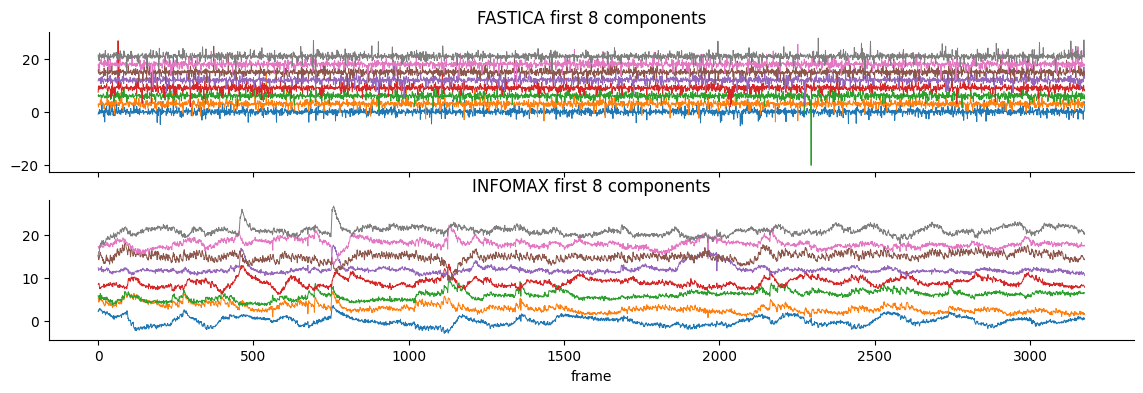

In [7]:
component_count = min(8, n_components)
fig, axes = plt.subplots(len(results), 1, figsize=(14, 2.0 * len(results)), sharex=True)
if len(results) == 1:
    axes = [axes]
for ax, (method, result) in zip(axes, results.items()):
    for comp_idx in range(component_count):
        ax.plot(result.ic_comps[:, comp_idx] + comp_idx * 3, lw=0.7, label=f"IC {comp_idx}")
    ax.set_title(f"{method.upper()} first {component_count} components")
axes[-1].set_xlabel("frame");


In [8]:
for method, result in results.items():
    if result.saved_paths:
        print(f"{method}:")
        for label, path in result.saved_paths.items():
            print(f"  {label}: {path.relative_to(PROJECT_ROOT)}")
    else:
        print(
            f"{method}: not saved; set SAVE_DECOMPOSITION_OUTPUTS = True and rerun the decomposition cell "
            f"to write artifacts under {result.output_dir.relative_to(PROJECT_ROOT)}"
        )


fastica:
  components: outputs/linear/v2a-RSNs/220127_F4_run2_fluorescence/fastica/components_fastica_220127_F4_run2_fluorescence.npy
  spectra: outputs/linear/v2a-RSNs/220127_F4_run2_fluorescence/fastica/spectra_fastica_220127_F4_run2_fluorescence.npy
  mixing: outputs/linear/v2a-RSNs/220127_F4_run2_fluorescence/fastica/mixing_fastica_220127_F4_run2_fluorescence.npy
  mean: outputs/linear/v2a-RSNs/220127_F4_run2_fluorescence/fastica/mean_fastica_220127_F4_run2_fluorescence.npy
  metadata: outputs/linear/v2a-RSNs/220127_F4_run2_fluorescence/fastica/metadata_fastica_220127_F4_run2_fluorescence.json
infomax:
  components: outputs/linear/v2a-RSNs/220127_F4_run2_fluorescence/infomax/components_infomax_220127_F4_run2_fluorescence.npy
  spectra: outputs/linear/v2a-RSNs/220127_F4_run2_fluorescence/infomax/spectra_infomax_220127_F4_run2_fluorescence.npy
  mixing: outputs/linear/v2a-RSNs/220127_F4_run2_fluorescence/infomax/mixing_infomax_220127_F4_run2_fluorescence.npy
  mean: outputs/linear/v2